<a href="https://colab.research.google.com/github/SEC-API-io/sec-api-cookbook/blob/main/notebooks/form-8k/8k-tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analyze 8-K Filings & Material Event Disclosure Activity

This Python tutorial is designed to guide you through the intricacies of working with 8-K filings using Python. It provides a comprehensive understanding and practical approach to managing and analyzing 8-K filings using various data visualization methods.

Firstly, we'll explore the basics of 8-K filings - understanding what they are, how they are structured, and who typically files them. We'll break down the various sections or items included in these filings and explain what events typically trigger the disclosure of each section.

Our tutorial then takes a practical turn, showing you how to retrieve all 8-K filings, and how to filter and find specific 8-Ks that disclose particular items. This section is especially useful for narrowing down the vast universe of 8Ks to those that are most relevant to your analysis.

![example-visualization-of-8-k-item-volumes-per-year](https://i.imgur.com/gcgEzFv.png)

## Form 8-K Overview

Publicly traded companies based in the United States that are registered with the SEC must submit Form 8-K, also known as “Current Report”, when certain specified events materialize. Upon the occurrence of a material event that fits into any of the 33 SEC-defined event categories, the company is obligated to disclose the event within four business days. Unlike 10-K or 10-Q filings, 8-Ks are event-driven, triggered by specific occurrences rather than a scheduled timeline. The content of Form 8-K is organized into distinct sections, each labeled with an item number (e.g., Item 1.01, Item 5.02, etc.), where each section corresponds to a specific type of event disclosing information about it. Among the 33 event categories, Item 8.01 serves as a "catch-all" provision. This category allows companies to disclose any event not specifically required under other sections but considered important by the company to its security holders. A single 8-K filing may include one or several of these sections, depending on the nature and number of events that need reporting.

Examples of events that must be reported on Form 8-K include entering or terminating significant agreements (Item 1.01 and 1.02), such as credit and merger agreements, filing for bankruptcy (Item 1.03), notices of delisting of a company's stock (3.01), identification of errors in financial statements (Item 4.02), and changes in the company's leadership including CEO, CFO, and board members (Item 5.02), among others. For a comprehensive list of all 33 event categories, please refer to section [List of Form 8-K Events and Items](#Overview-of-8-K-Items-and-Triggering-Event-Categories).

The obligation for companies to disclose material events through Form 8-K is mandated by Section 13 of the Securities Exchange Act of 1934. Notably, the regulation specifies that failing to file a report on Form 8-K, when required under specific items (specifically, Items 1.01, 1.02, 1.05, 2.03, 2.04, 2.05, 2.06, 4.02(a), 5.02(e), or 6.03), does not constitute a breach of certain anti-fraud provisions. These provisions include 15 U.S.C. 78j(b) and SEC Rule 240.10b–5. Therefore, while non-compliance with these filing requirements does not align with the regulation, it is not regarded as a violation of the mentioned anti-fraud rules. However, it's important to acknowledge that other repercussions may still be applicable.

Companies, such as Alibaba, based outside the United States with securities traded on U.S. markets are classified as foreign private issuers. Instead of filing Form 8-K, these companies are required to file Form 6-K. It's important to note that our analysis focuses exclusively on companies filing Form 8-K and does not include those classified as foreign private issuers and filing Form 6-K.


### Furnished vs Filed

A common phrase often found in 8-K and other filings is:

> [...] the information in this disclosure is deemed to have been furnished and shall not be deemed to be "filed" [...]

The terms "furnished" and "deemed to be filed" have specific meanings and implications, particularly regarding the legal responsibilities of the filing company and how the information is used. The choice between furnishing and filing information with the SEC often depends on the nature of the information and the level of liability the company is willing to accept for that information. Furnished information is made publicly available but with less legal responsibility for the issuer, whereas information that is deemed to be filed is fully subject to SEC filing rules and associated liabilities.

#### Furnished

When a document is "furnished" to the SEC, it means that the information is provided to the SEC and made publicly available, but it is not officially filed as part of the company’s permanent record with the SEC. Information that is furnished is generally not subject to the same level of legal scrutiny or liability for accuracy as information that is filed. For example, a company may furnish information under Item 2.02 or Item 7.01 (such as earnings releases or other press releases) that it is not willing to stand behind in the same way as it would for filed information. Information that is furnished is not incorporated by reference into other filings (like registration statements or proxy statements), unless the company specifically decides to do so.

#### Deemed to be Filed

On the other hand, when a document is "deemed to be filed", it carries the full legal implications of an SEC filing. This means it is officially part of the company's SEC filings and permanent record. Documents that are deemed to be filed are subject to the SEC's rules and regulations regarding accuracy and completeness. Companies and their management can be held legally responsible for the content of these filings. This includes potential liability under the Securities Act of 1933 and the Securities Exchange Act of 1934 for any misleading statements or material omissions. Such information is typically incorporated by reference into the company’s other filings, like registration statements for securities offerings or annual proxy statements. This means the information can be used and relied upon in various legal and regulatory contexts.

### Incorporated by Reference

Another common phrase seen in 8-K and other filings is:

> [...] information shall not be incorporated by reference into any filing [...]

The phrase "is not incorporated by reference into other filings" pertains to how certain documents submitted to the SEC are used in subsequent filings. To understand this, it's important to grasp what "incorporation by reference" means.

Incorporation by reference is a method used by companies to efficiently reuse or refer to previously filed information with the SEC in subsequent filings. Instead of repeating the same information, a company can reference the document where the information was initially provided. This makes filings more efficient and reduces the administrative burden. It allows the content of one document to be legally included in another document by simply referring to it. In other words, the referenced document is treated as part of the new filing as if it were fully included in it.

When a document or information "is not incorporated by reference into other filings," it means that the information in that document is not automatically considered a part of the company's other, later SEC filings. The information can still be accessed and reviewed in its original filing, but it is not legally considered part of the content of subsequent filings. This is significant because it affects how the information is used for legal and regulatory purposes. For example, information not incorporated by reference might not be used to satisfy disclosure requirements in future filings. This is often the case with information that is "furnished" to the SEC (such as certain information in Form 8-K) rather than "filed." Companies might choose not to incorporate certain information by reference to avoid the higher legal scrutiny or potential liability associated with "filed" information.


## 8-K Items and Event Examples

As outlined earlier, the 33 distinct event categories defined by the SEC for Form 8-K reporting each correspond to a specific item section. To illustrate the diversity of content that can be published under the same event category, let's consider three different examples of events along with their corresponding item sections, referencing actual content from various filings.

<!-- For example, when a company enters into a significant definitive agreement, it reports this under Item 1.01. Significant definitive agreements cover a broad spectrum of contracts and arrangements. For instance, these include equity distribution agreements, where a company notifies shareholders about the issuance and sale of its shares to a third party for capital raising purposes. They can also involve entering into a master data license agreement, a credit agreement, asset and note purchase agreements, or merger agreements, among others.

When a company identifies errors in its previously reported financial statements as filed on Form 10-Q or 10-K, it is required to report these findings under Item 4.02, titled "Non-Reliance on Previously Issued Financial Statements or a Related Audit Report or Completed Interim Review." This disclosure should specify the affected financial statements, a rationale for why the previously issued financial statements can no longer be deemed reliable (e.g. accounting errors, miscalculations, changes in accounting principles, etc), and a timeline for fixing the issue. Furthermore, Item 4.02 should address the expected impact of these errors on the company’s financial position and operating results. Additionally, the company is obliged to outline its strategy for correcting and reissuing the financial statements. This plan should encompass proposed timelines for publishing the amended financials and measures being implemented to avoid similar issues in the future.

Similarly, changes in company leadership, such as a CEO transition or changes to a company’s board, are reported under Item 5.02.  -->

### Example: Item 3.01 Notice of Delisting or Failure to Satisfy a Listing Rule

When a company receives a notice from a securities exchange (e.g., NASDAQ) concerning the listing status of its stocks, it is required to disclose this information under Item 3.01, titled "Notice of Delisting or Failure to Satisfy a Continued Listing Rule or Standard; Transfer of Listing." For instance, these notices might include a notification that the company's stock price has fallen below \\$1, failing to meet NASDAQ's minimum price requirement of \$1 per share. In such cases, NASDAQ typically grants the company a period of 180 days to regain compliance. If the company fails to meet this requirement within the specified timeframe, it faces the risk of being delisted from the exchange.

Item 3.01 encompasses four distinct sub-categories of events for which disclosure is required:

**1. Delisting Notices**

When a company is notified about its stocks not meeting the required standards for continued listing, or if there is an intent to delist its stocks, the company must:
  - Report the date on which it received this notification.
  - Identify the specific listing standards that it is failing to meet.
  - Detail its plan to remedy these issues.

**2. Self-Identified Noncompliance**

In situations where a company self-determines its noncompliance with listing standards and communicates this to the exchange or association, it is required to:
  - Disclose the date it reported this noncompliance.
  - Clearly state the listing standards it is failing to meet.
  - Describe its strategy to correct the noncompliance.

**3. Handling Public Reprimands**

If the company receives a public reprimand or similar notice, rather than delisting, for not meeting listing standards, it should:
  - Announce the date of receiving this communication.
  - Provide a summary of the communication's contents.

**4. Voluntary Withdrawal or Transfer of Listing**

If the company decides to voluntarily withdraw its stocks from a listing or transfer them to another exchange or system, it must:
  - Describe the actions taken for this change.
  - Specify the date these actions were executed.


#### Item 3.01 - Content Example

![8-k-item-3-01-notice-of-delisting-example](https://i.imgur.com/SdUiYEfh.png)

[Source](https://www.sec.gov/Archives/edgar/data/1506983/000149315223043264/form8-k.htm)

### Example: Item 4.02 Non-Reliance on Previously Issued Financial Statements

When a company identifies errors in its previously reported financial statements as filed on Form 10-Q or 10-K, it is required to report these findings under Item 4.02, titled "Non-Reliance on Previously Issued Financial Statements or a Related Audit Report or Completed Interim Review." This disclosure should specify the affected financial statements, a rationale for why the previously issued financial statements can no longer be deemed reliable (e.g. accounting errors, miscalculations, changes in accounting principles, etc), the impact on the company's financial position, and a strategy and timeline for fixing the issue. The determination of non-reliance can be made either by the company’s management or by its auditors.

#### Item 4.02 - Content Example

![8-k-item-4-02-example](https://i.imgur.com/6U9WMaGh.png)

[Source](https://www.sec.gov/Archives/edgar/data/863894/000119312523277950/d850611d8k.htm)

### Example: Item 7.01 Regulation FD ("Non-Selective") Disclosure

For disclosures not filed under Item 8.01 ("catch-all"), companies should use Item 7.01 exclusively for information in accordance with Regulation FD (17 CFR 243.100 through 243.103). Regulation FD (Fair Disclosure) is designed to ensure that all investors, both large and small, have equal access to material, non-public information about publicly traded companies. Under Regulation FD, if a company discloses material, non-public information to certain individuals (like analysts, large investors, or other market professionals), it must simultaneously (or promptly thereafter) disclose that information to the public. It ensures that companies do not selectively disclose material nonpublic information to certain individuals. The key factor is that the information under Item 7.01 is material to investors and not yet publicly available.

Examples of the types of information that a company might disclose under Item 7.01 include:

- **Earnings Guidance**: If a company provides earnings forecasts or updates to a select group, this information should be simultaneously disclosed to the public to ensure all investors have access to it at the same time.
- **Changes in Previously Reported Financial Results**: If a company informs a select few about changes in its financial results or financial condition that differ from previously reported figures, this information should be publicly disclosed.
- **Mergers and Acquisitions**: If a company discusses potential or pending mergers and acquisitions with select individuals before public announcement, this information should be disclosed to all investors at the same time.
- **New Contracts or Business Relationships**: Information about significant new contracts, partnerships, or business relationships, especially if they are expected to have a material impact on the company’s performance.
- **Management Changes**: Information about major changes in senior management or key personnel that is not yet public.
- **Product Developments**: Details about significant developments in products or technology, especially if they are likely to impact the company's business prospects.
- **Regulatory Approvals or Decisions**: Information regarding significant regulatory approvals or decisions affecting the company's operations or products.
- **Legal Matters**: Developments in significant legal or regulatory proceedings that could affect the company's financial status or operations.
- **Dividend Changes or Stock Buybacks**: Information about changes in dividend policies or decisions about stock buybacks.

#### Item 7.01 - Content Example

![item-7-01-in-8-k-filing](https://i.imgur.com/CCnl3Fth.png)

[Source](https://www.sec.gov/Archives/edgar/data/1855457/000185545723000050/kore-20231201.htm)

## Getting Started

Let's begin by gathering all 8-K filings along with their metadata, including the various items disclosed in each 8-K, the publication date and time of the material event disclosure, the filing URL, the publisher's details (like ticker, CIK, and company name), among others. To simplify the process, we have compiled a list of metadata for all 8-Ks spanning from 1994 to 2022. While a detailed walkthrough of data collection is beyond this tutorial's scope, we'll focus on outlining the essential steps you need to follow.

To effectively fetch all Form 8-K filings and their metadata from 1994 to 2022, you can utilize the [Query API](https://sec-api.io/docs/query-api). This API enables detailed searches of EDGAR filings using various search expressions. The process involves setting up and executing queries that can filter filings based on form type, specific items within the forms, and the filing date.

Your primary focus would be on setting up queries for Form 8-K filings. Rather than filtering by specific items disclosed in the filings via the `items` filter, you would use the `filedAt` date range filter to cover the entire period from 1994 to 2022. This is essential due to the sheer volume of data and the limit of 10,000 results per query.

You'll need to paginate through the results universe systematically. Start with an initial query for a specific year and month, for example, January 2022, `filedAt:[2022-01-01 TO 2022-01-31]`. After executing this query, increment the `from` parameter by 200 for each subsequent query. This method allows you to paginate through the database effectively, ensuring you don't miss any filings. The `size` parameter in your query dictates the number of results you retrieve in each batch, with the maximum being 200. Keep this parameter static at all times.

To get comfortable with the query setup, it’s advisable to use the [query sandbox](https://sec-api.io/sandbox). This tool allows you to test your queries without implementing them in Python immediately.

The process is illustrated with two JSON query examples. The first example fetches all 8-K filings using the `filedAt` date range:

```json
{
    "query": "formType:\"8-K\" and filedAt:[{YEAR}-{MONTH}-01 TO {YEAR}-{MONTH}-31]",
    "from": "0",
    "size": "200",
    "sort": [{ "filedAt": { "order": "desc" } }]
}
```

The second example is tailored to find 8-K filings that specifically disclose Item 7.01:

```json
{
    "query": "formType:\"8-K\" AND items:\"7.01\"",
    "from": "0",
    "size": "200",
    "sort": [{ "filedAt": { "order": "desc" } }]
}
```

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.style as style
import modules.helpers as helpers

import importlib
importlib.reload(helpers)

style.use('default')

params = {
   'axes.labelsize': 8,
   'font.size': 8,
   'legend.fontsize': 8,
   'xtick.labelsize': 8,
   'ytick.labelsize': 8,
   'text.usetex': False,
   'font.family': 'sans-serif',
}

plt.rcParams.update(params)

Let's load all metadata of 8-K items filed from 1994 to 2022 into the dataframe `items_8k`. The resulting dataframe has

In [ ]:
items_8k, item_id_to_label_map = helpers.get_8k_items()
items_8k

,accessionNo,formType,filedAt,itemId,itemLabel,year,month
0,0000950168-94-000001,8-K,1994-01-04 00:00:00-05:00,3.00,Bankruptcy or receivership,1994,1
1,0000950112-94-000002,8-K,1994-01-04 00:00:00-05:00,5.00,Other events,1994,1
2,0000950112-94-000002,8-K,1994-01-04 00:00:00-05:00,7.00,Financial statements and exhibits,1994,1
3,0000203077-94-000002,8-K,1994-01-04 00:00:00-05:00,1.00,Changes in control of registrant,1994,1
4,0000950144-94-000006,8-K,1994-01-04 00:00:00-05:00,2.00,Acquisition or disposition of assets,1994,1
...,...,...,...,...,...,...,...
3694287,0001104659-22-131441,8-K,2022-12-30 18:23:08-05:00,9.01,Financial Statements and Exhibits,2022,12
3694288,0001104659-22-131441,8-K,2022-12-30 18:23:08-05:00,2.03,Creation of a Direct Financial Obligation or a...,2022,12
3694289,0001104659-22-131459,8-K,2022-12-30 21:03:03-05:00,9.01,Financial Statements and Exhibits,2022,12
3694290,0001104659-22-131459,8-K,2022-12-30 21:03:03-05:00,1.01,Entry into a Material Definitive Agreement,2022,12


Our dataframe contains 3.6 million 8-K items. Some of these represent individual filings, while others are connected to the same filing as they were published together in a single document.

## Distribution and Trends of 8-K Items per Year

With all 8-K items now loaded, we're set to analyze how frequently specific events were disclosed under each item annually. Additionally, we'll examine the impact of the Sarbanes-Oxley Act on these trends spanning from 1994 to 2022.

In [ ]:
item_count = items_8k.groupby(['year', 'itemId']).size().reset_index(name='count')
item_count_pivot = item_count.pivot(index='year', columns='itemId', values='count').fillna(0)
item_count_pivot[-5:]

itemId,1.00,1.01,1.02,1.03,1.04,2.00,2.01,2.02,2.03,2.04,...,7.00,7.01,8.00,8.01,9.00,9.01,10.00,11.00,12.00,13.00
year,,,,,,,,,,,,,,,,,,,,,
2018,0.0,10620.0,1080.0,85.0,11.0,0.0,1715.0,17488.0,4695.0,124.0,...,0.0,14218.0,0.0,16584.0,0.0,51266.0,0.0,0.0,0.0,0.0
2019,0.0,10146.0,929.0,112.0,16.0,0.0,1512.0,17087.0,4548.0,154.0,...,0.0,14008.0,0.0,15877.0,0.0,49808.0,0.0,0.0,0.0,0.0
2020,0.0,11172.0,966.0,175.0,8.0,0.0,1247.0,17643.0,5398.0,194.0,...,0.0,16488.0,0.0,19888.0,0.0,54548.0,0.0,0.0,0.0,0.0
2021,0.0,12644.0,1139.0,71.0,10.0,0.0,1756.0,18396.0,5090.0,117.0,...,0.0,17014.0,0.0,19658.0,0.0,57950.0,0.0,0.0,0.0,0.0
2022,0.0,10088.0,1040.0,42.0,11.0,0.0,1335.0,18851.0,4757.0,120.0,...,0.0,16409.0,0.0,15745.0,0.0,53748.0,0.0,0.0,0.0,0.0


In [ ]:
top_items = item_count_pivot.T.sum(axis=1).sort_values(ascending=False).head(10).index.to_list()
print("Top 10 most often disclosed events:")
top_items

Top 10 most often disclosed events:


[9.01, 8.01, 2.02, 5.02, 7.01, 1.01, 7.0, 5.0, 2.03, 5.07]

In [ ]:
item_stats = pd.DataFrame(item_count_pivot.T.sum(axis=1).sort_values(ascending=False))
item_stats.columns = ['count']
item_stats['percentage'] = round(item_stats['count'] / item_stats['count'].sum() * 100, 1)
item_stats.index = item_stats.index.map(str)
item_stats['label'] = item_stats.index.map(item_id_to_label_map)
item_stats[:10]

,count,percentage,label
itemId,,,
9.01,1121732.0,30.4,Financial Statements and Exhibits
8.01,384879.0,10.4,Other Events
2.02,356403.0,9.6,Results of Operations and Financial Condition
5.02,266982.0,7.2,Departure of Directors or Certain Officers; El...
7.01,264535.0,7.2,Regulation FD Disclosure
1.01,260511.0,7.1,Entry into a Material Definitive Agreement
7.0,238649.0,6.5,NaN
5.0,202907.0,5.5,NaN
2.03,88347.0,2.4,Creation of a Direct Financial Obligation or a...


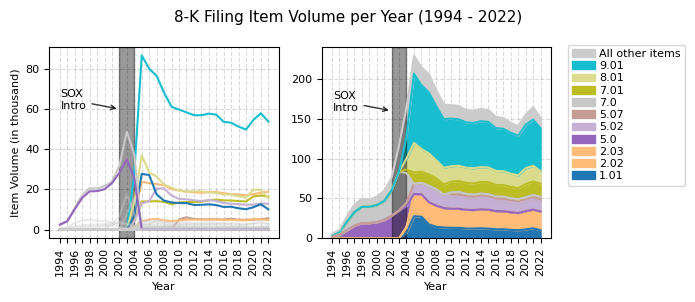

In [ ]:
figsize=(7, 3)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

#####################
# Data preparation
#####################

data_left = item_count_pivot.copy()
data_right = data_left.copy()
data_right['All other items'] = data_right[data_right.columns.difference(top_items)].sum(axis=1)
data_right = data_right[top_items + ['All other items']]

columns = data_right.columns
colors = plt.cm.tab20(np.linspace(0, 1, len(data_left.columns)))
light_grey_see_through = [0.8, 0.8, 0.8, 0.4]
colormap = dict(zip(data_left, colors))
colormap['All other items'] = light_grey_see_through

for i in colormap:
  if i not in top_items:
    colormap[i] = light_grey_see_through

data_left = data_left.T.sort_values(2022, ascending=False).T
data_right = data_right.T.sort_values(2022, ascending=True).T

# move 'All other items' to the end
all_other_items = data_right['All other items']
data_right = data_right[data_right.columns.difference(['All other items'])]
data_right['All other items'] = all_other_items

#####################
# Left Plot
#####################

data_left.plot(ax=ax1, color=[colormap[c] for c in data_left.columns])
ax1.set_title(""), ax1.set_ylabel("Item Volume (in thousand)"), ax1.set_xlabel("Year"),
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: format(int(x)/1000, ',.0f')))
ax1.grid(True), ax1.set_axisbelow(True), ax1.grid(color='gray', linestyle='dashed', alpha=0.3)
ax1.set_xticks(range(1994, 2023)), ax1.set_xticklabels(range(1994, 2023), rotation=90, ha='center')
ax1.legend().set_visible(False)

ax1.axvspan(2002, 2004, alpha=0.4, color='black'); ax1.set_axisbelow(True)
ax1.annotate('SOX\nIntro', xy=(2002, 60000), xytext=(1994.1, 60000), arrowprops=dict(arrowstyle='->', color='black', alpha=0.8))

# hide every 2nd tick label
for label in ax1.xaxis.get_ticklabels()[1::2]:
    label.set_visible(False)

#####################
# Right Plot
#####################

colormap['All other items'] = [0.8, 0.8, 0.8, 1.0]
data_right.plot(kind='area', stacked=True, ax=ax2, color=[colormap[c] for c in data_right.columns])
ax2.set_title(""), ax2.set_ylabel(""), ax2.set_xlabel("Year"),
ax2.set_xticks(range(1994, 2023)), ax2.set_xticklabels(range(1994, 2023), rotation=90, ha='center')
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: format(int(x)/1000, ',.0f')))
ax2.grid(True), ax2.set_axisbelow(True), ax2.grid(color='gray', linestyle='dashed', alpha=0.3)
handles, labels = ax2.get_legend_handles_labels()
ax2.legend(reversed(handles), reversed(labels), bbox_to_anchor=(1.05, 1.04), loc='upper left', handletextpad=0.4, labelspacing=0.2)

# hide every 2nd tick label
for label in ax2.xaxis.get_ticklabels()[1::2]:
    label.set_visible(False)

ax2.axvspan(2002, 2004, alpha=0.4, color='black'); ax2.set_axisbelow(True)
ax2.annotate('SOX\nIntro', xy=(2002, 160000), xytext=(1994.1, 160000), arrowprops=dict(arrowstyle='->', color='black', alpha=0.8))

fig.suptitle('8-K Filing Item Volume per Year (1994 - 2022)', fontsize=11)
plt.tight_layout()
plt.show()

### Observations

The peak in the number of event disclosures on Form 8-K was observed in 2005, with approximately 250,000 events reported that year. Following this peak, there was a general year-over-year decline in the number of disclosures. However, an exception occurred during 2020 and 2021, amidst the COVID-19 pandemic, when there was a significant increase in 8-K filings.

The rollout of the Sarbanes-Oxley Act (SOX) from 2002 to 2004, and its subsequent implementation for smaller filers, had a pronounced impact on the disclosure activities of companies. This effect is evident in the surge of disclosures under various items, notably Item 9.01 "Financial Statements and Exhibits," Item 8.01 "Other Events," and Item 1.01 "Entry into a Material Definitive Agreement," among others.

Item 9.01, which was first mandated by SOX, saw its annual disclosure volume reach a peak in 2005. Since then, the frequency of disclosures under Item 9.01 has consistently decreased, mirroring the overall reduction in disclosure activity across all other items.

Notably, Item 9.01 constitutes the largest event category in terms of disclosures. It represents 30% of all event disclosures from 1994 to 2022, making it the category with the most information published. Moreover, the top three items – 9.01, 8.01, and 2.02 – collectively account for 50% of all event disclosures in the same period. This data underscores the significant role these items play in corporate reporting and investor communication.


In [ ]:
item_count_2005 = item_count_pivot.loc[2005:, (item_count_pivot.loc[2005:] != 0.0).any(axis=0)]

In [ ]:
def get_single_boxplot_stats(data):
    minimum = np.min(data)
    Q1 = np.percentile(data, 25)
    median = np.percentile(data, 50)
    Q3 = np.percentile(data, 75)
    maximum = np.max(data)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return {
        "N": len(data),
        "Min": minimum,
        "Q1": Q1, # (25th Percentile)
        "Median": median, # (50th Percentile)
        "Q3": Q3, # (75th Percentile)
        "Max": maximum,
        "IQR": IQR, # Represents the middle 50% of the data (i.e. Q3 - Q1)
        "Lower": lower_bound, # Lower bound (for outliers)
        "Upper": upper_bound, # Upper bound (for outliers)
    }

In [ ]:
# compute descriptive stats for each month across all years
def get_boxplot_stats(df):
    output = {}
    for column in df.columns:
        output[f"{column}"] = get_single_boxplot_stats(df[column])

    return pd.DataFrame(output).T.astype(int)

In [ ]:
item_count_2005_stats = get_boxplot_stats(item_count_2005)

In [ ]:
item_count_2005_stats[item_count_2005_stats['Q3']>100]

,N,Min,Q1,Median,Q3,Max,IQR,Lower,Upper
1.01,18,10088,11317,12472,13466,27731,2148,8094,16689
1.02,18,929,1077,1145,1352,2239,275,663,1765
1.03,18,42,110,143,193,434,83,-14,318
2.01,18,1247,1772,2287,2529,4190,757,636,3665
2.02,18,17087,18200,18735,20017,23789,1817,15474,22743
2.03,18,4164,4596,4933,5027,5398,431,3949,5674
2.04,18,117,155,190,338,510,183,-119,613
2.05,18,122,273,304,525,750,252,-104,904
2.06,18,54,98,132,291,466,193,-190,581
3.01,18,647,908,1026,1342,1581,434,257,1993


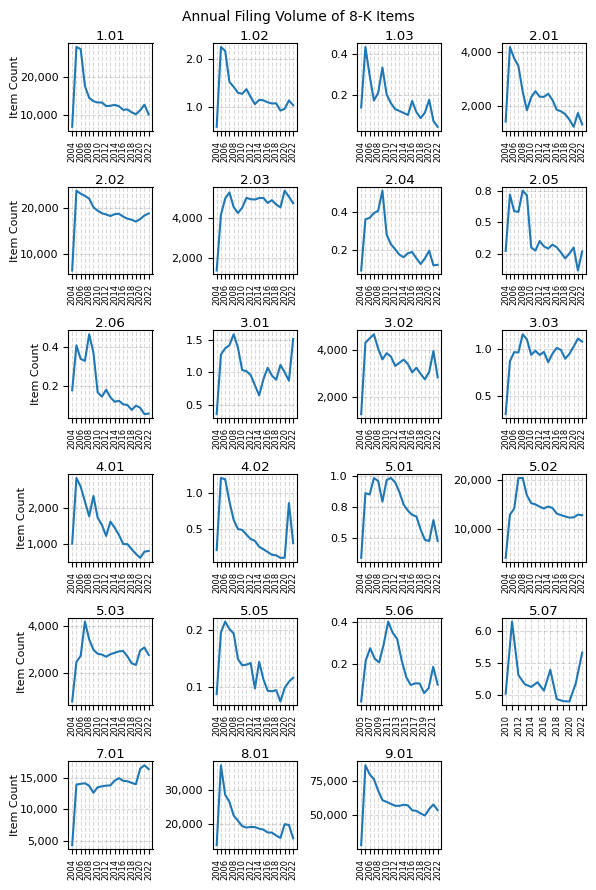

In [ ]:
import matplotlib.gridspec as gridspec

def format_y_axis(x, p):
  return format(int(x), ',')

def format_y_axis_000(x, p):
  return format(int(int(x)/1000), ',.0f')

def format_y_axis_000_2(x, p):
  return format(int(x)/1000, ',.1f')


figure, axes = plt.subplots(6, 4, figsize=(6, 9))
gs = gridspec.GridSpec(nrows=6, ncols=2, height_ratios=[1]*6, hspace=0, wspace=0)

filtered = item_count_2005_stats[item_count_2005_stats['Q3']>100]

for i, item_id in enumerate(filtered[:24].index):
  items_x = items_8k[items_8k['itemId'] == float(item_id)]
  item_x_count = items_x.groupby(['year']).size().reset_index(name='count').fillna(0)
  item_x_count.index = item_x_count['year']
  ax = axes[i//4, i%4]
  item_x_count['count'].plot(kind='line', ax=ax)
  title = f"{item_id}"
  x_label = ""
  y_label = "Item Count" if i % 4 == 0 else ""
  ax.set_title(title, pad=0); ax.set_ylabel(y_label); ax.set_xlabel(x_label)
  ax.set_xticks(item_x_count['year'].tolist())
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', fontsize=6)

  for label in ax.xaxis.get_ticklabels()[1::2]:
    label.set_visible(False)

  ytick_labels = [int(x.get_text()) for x in ax.yaxis.get_ticklabels()]
  max_y = max(ytick_labels)
  min_y = min(ytick_labels)
  all_divisible_by_1000 = all(value % 1000 == 0 for value in ytick_labels)

  if all_divisible_by_1000:
    formatter = mtick.FuncFormatter(format_y_axis)
  else:
    formatter = mtick.FuncFormatter(format_y_axis_000_2)

  ax.yaxis.set_major_formatter(formatter)
  ax.yaxis.labelpad = 0; ax.xaxis.labelpad = 10
  ax.grid(True), ax.set_axisbelow(True), ax.grid(color='gray', linestyle='dashed', alpha=0.3)

axes[5, 3].axis('off')

figure.suptitle('Annual Filing Volume of 8-K Items', fontsize=10)

plt.tight_layout()
plt.show()

**Item 7.01:** The trend in disclosures under Item 7.01, "Regulation FD Disclosure," stands out among the 33 item groups in Form 8-K filings. Despite a year-over-year decrease in the number of listed companies since the peak in 2000, disclosures under Item 7.01 have consistently increased, reaching an unprecedented level in 2021. This raises an intriguing question: Are companies increasingly opting to disclose information under Item 7.01, taking advantage of the "furnished but not filed" provision, thereby potentially mitigating their liability risks? This shift suggests that companies may be strategically using Item 7.01 to share information that might have been reported under other items in the past. The "furnished but not filed" clause associated with Item 7.01 means that the information provided under this item is not officially "filed" with the SEC and, therefore, may carry different legal implications. This approach could be seen as a way for companies to balance the need for transparency with the desire to manage potential liability risks associated with formal SEC filings.

**Delisting and Exchange Non-Compliance Notices (Item 3.01):** From 2010 to 2021, the frequency of delisting and exchange non-compliance notices (particularly regarding the \\$1 per share price bid minimum requirement) remained relatively stable. A significant increase, exceeding 50%, occurred from 2021 to 2022. This surge, primarily related to the $1 per share minimum price requirement of major exchanges, notably reflects the market downturn experienced in 2022. The highest incidence of such notices was during the Global Financial Crisis (GFC) in 2008, driven by widespread selling pressure in the market.

**Non-Reliance on Previously Issued Financial Statements (Item 4.02):** The peak in companies reporting non-reliance disclosures occurred in 2005 and 2006, just before the GFC, and exhibited a downward trend until 2020, hitting an all-time low that year, and indicating minimal reporting of errors and misstatements in financial statements since the introduction of this item in 2004. However, from 2020 to 2021, the number of non-reliance reports more than doubled, underscoring the significant impact of the COVID-19 pandemic on many businesses.

**Matters Submitted to a Vote of Security Holders (Item 5.07):** Item 5.07 was first used in 2010 and reached its peak in 2011, with over 6,000 disclosures. Since 2011, there was a year-over-year decline in the number of disclosures under Item 5.07, reaching an all-time low in 2020. The trend reversed sharply from 2020 to 2022, with an increase in companies disclosing Item 5.07. This indicates that more companies submitted matters to a vote of security holders in 2022, making it the second-highest year for such disclosures.

<!-- Constant:
- 2.03 “Creation of a Direct Financial Obligation or an Obligation under an Off-Balance Sheet Arrangement of a Registrant” is constant
- 3.03 Material Modifications to Rights of Security Holders
- 5.03 Amendments to Articles of Incorporation or Bylaws; Change in Fiscal Year


Declining with number of entities filing 8-Ks, i.e. clear downward trend for the following events
- Clear downward trend of item disclosure for: 9.01, 8.01, 1.01, 5.02, etc.
- 1.01, 1.02, 1.03, 2.01, 2.04, 2.05, 2.06, 4.01, 5.01, 5.02, 8.01, 9.01 -->


## 8-K Filing and Item Volume per Month

Next, we'll explore potential seasonal filing patterns by analyzing variations in disclosure activity each month and identifying any long-term trends over the past two decades. To achieve this, we'll create a pivot table with months (January through December) as columns, years from 1994 to 2022 as rows, and the cells populated with the count of unique 8-K filings, identified by their accession numbers, rather than item counts.

In [ ]:
items_8k_acc_no = items_8k.drop_duplicates(subset=['accessionNo'], keep='first')
items_8k_acc_no_pivot = items_8k_acc_no.groupby(['year', 'month']).size().reset_index(name='count').fillna(0)
items_8k_acc_no_pivot  = items_8k_acc_no_pivot.pivot(index='year', columns='month', values='count').fillna(0)
items_8k_acc_no_pivot.columns = items_8k_acc_no_pivot.columns.astype(str)
items_8k_acc_no_pivot

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
1994,363,332,330,303,268,268,352,297,286,377,276,340
1995,406,435,470,540,576,617,567,600,576,821,686,742
1996,864,789,804,890,1425,1662,1931,1593,1655,2103,1815,1986
1997,2247,1990,2080,2136,1875,2050,2430,2036,2200,2632,2065,2648
1998,2620,2419,2609,2543,2251,2592,2771,2243,2301,2797,2282,2877
1999,2463,2430,2639,2565,2212,2459,2592,2285,2299,2590,2403,2730
2000,2690,2848,2746,2359,2500,2506,2407,2417,2412,2857,2870,2704
2001,3445,2703,3070,2989,3164,2736,3060,3038,2437,3628,2984,3002
2002,3426,3009,3157,3695,3812,3475,4039,5293,3527,4409,4439,3826


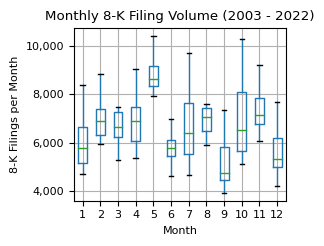

In [ ]:
fig, ax = plt.subplots(figsize=(3, 2.5))
items_8k_acc_no_pivot.loc[2003:].boxplot(ax=ax, grid=True, showfliers=False)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(format_y_axis))
ax.set_title("Monthly 8-K Filing Volume (2003 - 2022)"), ax.set_ylabel("8-K Filings per Month"), ax.set_xlabel("Month")
plt.tight_layout()
plt.show()

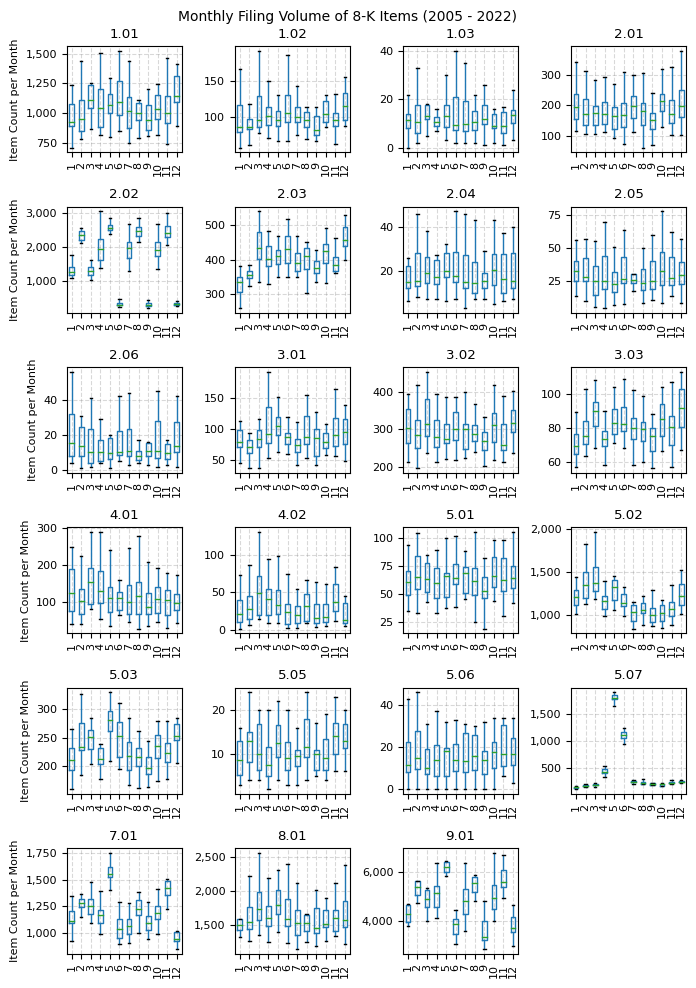

In [ ]:
figure, axes = plt.subplots(6, 4, figsize=(7, 10))

filtered = item_count_2005_stats[item_count_2005_stats['Q3']>100]

for i, item_id in enumerate(filtered.index):
  items_x = items_8k[items_8k['itemId'] == float(item_id)]
  item_x_count = items_x.groupby(['year', 'month']).size().reset_index(name='count')
  item_x_count_piv = item_x_count.pivot(index='year', columns='month', values='count').fillna(0)
  ax = axes[i//4, i%4]
  item_x_count_piv.loc[2005:].boxplot(ax=ax, showfliers=False)
  title = f"{item_id}"
  x_label = ""
  y_label = "Item Count per Month" if i % 4 == 0 else ""
  ax.set_title(title), ax.set_ylabel(y_label), ax.set_xlabel(x_label)
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')
  ax.yaxis.set_major_formatter(mtick.FuncFormatter(format_y_axis))
  ax.grid(True), ax.set_axisbelow(True)
  ax.grid(True), ax.set_axisbelow(True), ax.grid(color='gray', linestyle='dashed', alpha=0.3)


axes[5, 3].axis('off')

figure.suptitle('Monthly Filing Volume of 8-K Items (2005 - 2022)', fontsize=10)

plt.tight_layout()
plt.show()

### Observations

Our analysis reveals distinct seasonal patterns in 8-K filing activities between 2003 and 2022. The identified monthly filing activities by item helps in understanding what drives the overall seasonal trends in 8-K disclosures.

1. **May Peak and September Trough**: May consistently emerges as the month with the highest number of 8-K filings, while September records the lowest. Interestingly, June experiences a sharp decline, ranking as the second-lowest month for filing activity, closely followed by January.

2. **Item-Specific Trends**:
   - **Item 5.07 "Submission of Matters to a Vote of Security Holders"**: This item demonstrates a pronounced pattern, peaking in May.
   - **Items 9.01 and 7.01**: These also significantly contribute to the heightened activity observed in May and the drop-off through September.
   - **Item 5.02**: The "Departure/Election of Directors/Officers and Compensatory Arrangements" category exhibits a clear seasonal pattern. The highest level of disclosures occurs in March, with the lowest in September, and an uptick observed towards the end of the year. This trend suggests that companies frequently implement changes in management and board of directors around or just before the release of their annual reports in 10-K filings during the first quarter. Additionally, there's a noticeable increase in December, possibly correlating with adjustments in compensation arrangements, as management might be aware of the approximate annual results by this time.

3. **Link to Filing Deadlines**:
   - **Item 2.02 "Results of Operations and Financial Condition" and Item 9.01**: These are tied to the 10-K and 10-Q filing deadlines. Notably, Item 2.02 disclosures are unusually sparse in June, September, and December, in contrast to the consistently high disclosures under Item 9.01 during these months, averaging 3,500 to 4,000 per month.

4. **Varied Patterns Across Other Items**: While some items display distinct patterns, others do not exhibit any discernible trend.


## Overview of 8-K Items and Triggering Event Categories

### Section 1 - Registrant’s Business and Operations

- 1.01: Entry into a Material Definitive Agreement
- 1.02: Termination of a Material Definitive Agreement
- 1.03: Bankruptcy or Receivership
- 1.04: Mine Safety - Reporting of Shutdowns and Patterns of Violations
- 1.05: Material Cybersecurity Incidents.

### Section 2 - Financial Information

- 2.01: Completion of Acquisition or Disposition of Assets
- 2.02: Results of Operations and Financial Condition
- 2.03: Creation of a Direct Financial Obligation or an Obligation under an Off-Balance Sheet Arrangement of a Registrant
- 2.04: Triggering Events That Accelerate or Increase a Direct Financial Obligation or an Obligation under an Off-Balance Sheet Arrangement
- 2.05: Cost Associated with Exit or Disposal Activities
- 2.06: Material Impairments

### Section 3 - Securities and Trading Markets
- 3.01: Notice of Delisting or Failure to Satisfy a Continued Listing Rule or Standard; Transfer of Listing
- 3.02: Unregistered Sales of Equity Securities
- 3.03: Material Modifications to Rights of Security Holders

### Section 4 - Matters Related to Accountants and Financial Statements
- 4.01: Changes in Registrant's Certifying Accountant
- 4.02: Non-Reliance on Previously Issued Financial Statements or a Related Audit Report or Completed Interim Review

### Section 5 - Corporate Governance and Management
- 5.01: Changes in Control of Registrant
- 5.02: Departure of Directors or Certain Officers; Election of Directors; Appointment of Certain Officers: Compensatory Arrangements of Certain Officers
- 5.03: Amendments to Articles of Incorporation or Bylaws; Change in Fiscal Year
- 5.04: Temporary Suspension of Trading Under Registrant's Employee Benefit Plans
- 5.05: Amendments to the Registrant's Code of Ethics, or Waiver of a Provision of the Code of Ethics
- 5.06: Change in Shell Company Status
- 5.07: Submission of Matters to a Vote of Security Holders
- 5.08: Shareholder Nominations Pursuant to Exchange Act Rule 14a-11

### Section 6 -Asset-Backed Securities
- 6.01: ABS Informational and Computational Material
- 6.02: Change of Servicer or Trustee
- 6.03: Change in Credit Enhancement or Other External Support
- 6.04: Failure to Make a Required Distribution
- 6.05: Securities Act Updating Disclosure
- 6.06: Static Pool
- 6.10: Alternative Filings of Asset-Backed Issuers

### Section 7 - Regulation FD
- 7.01: Regulation FD Disclosure

### Section 8 - Other Events
- 8.01: Other Events

### Section 9 - Financial Statements and Exhibits
- 9.01: Financial Statements and Exhibits



## References

**SEC.gov**
- [Form 8-K General Instructions](https://www.sec.gov/files/form8-k.pdf)

**8-K Related Regulations**
- [§ 240.13a-11 Current reports on Form 8-K](https://www.ecfr.gov/current/title-17/chapter-II/part-240/subpart-A/subject-group-ECFR057e83a8b5546d3/section-240.13a-11)
- [§ 249.308 Form 8-K, for current reports](https://www.ecfr.gov/current/title-17/chapter-II/part-249/subpart-D/section-249.308)
- [§ 240.10b-5 Employment of manipulative and deceptive devices](https://www.ecfr.gov/current/title-17/chapter-II/part-240/subpart-A/subject-group-ECFRbda83517ce4377f/section-240.10b-5)